In [1]:
!pip install livelossplot optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.2 MB/s eta 0:00:00


In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer, models
import numpy as np
import pandas as pd
import time
import pathlib
from livelossplot import PlotLosses

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
og_model_name = 'BAAI/bge-base-en-v1.5'
og_model_dims = 768
og_model_two = 'sentence-transformers/all-MiniLM-L12-v2'
og_model_two_dims = 384
og_model_three = 'intfloat/e5-base-v2'
og_model_three_dims = 768

classifier_layer = models.Dense(in_features=og_model_dims, 
                                out_features=5, 
                                activation_function=None)

model = SentenceTransformer(modules=[models.Transformer(og_model_name), 
                                     models.Pooling(768), 
                                     classifier_layer])
#do not update the weights of the original model, only train the classifier layer
for param in model[0].parameters():
    param.requires_grad = False

classification_layer_two = models.Dense(in_features=og_model_two_dims, 
                                        out_features=5, 
                                        activation_function=None)
model_two = SentenceTransformer(modules=[models.Transformer(og_model_two), 
                                         models.Pooling(og_model_two_dims), 
                                         classification_layer_two])
for param in model_two[0].parameters():
    param.requires_grad = False

classification_layer_three = models.Dense(in_features=og_model_three_dims, 
                                        out_features=5, 
                                        activation_function=None)
model_three = SentenceTransformer(modules=[models.Transformer(og_model_three),
                                            models.Pooling(og_model_three_dims), 
                                            classification_layer_three])
for param in model_three[0].parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: intfloat/e5-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [5]:
class PromptIDataset(Dataset):
    def __init__(self, csv_file):
        self.dataframe = pd.read_csv(csv_file)
        # The last five columns are the boolean labels, and the first column is the text
        self.texts = self.dataframe.iloc[:, 0].tolist()
        self.labels = self.dataframe.iloc[:, 1:].values

    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        return text, label

In [6]:
def train_model(model, loss_function, optimizer, train_loader, val_loader, device, epochs=10, output_path="./best_model.pth"):
    model.to(device)
    liveloss = PlotLosses()
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            texts, labels = batch
            
            # 1. Tokenize and move inputs to device
            inputs = model.tokenize(texts)
            inputs = {key: val.to(device) for key, val in inputs.items()}
            labels = labels.float().to(device)

            optimizer.zero_grad()
            
            # 2. Pass the tokenized dictionary to the model
            outputs = model(inputs) 
            
            # 3. Extract the dense layer predictions
            logits = outputs['sentence_embedding'] 
            
            loss = loss_function(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * len(labels)
        
        avg_train_loss = train_loss / len(train_loader.dataset)
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for texts, labels in val_loader:
                texts = list(texts)
                labels = labels.float().to(device)
                
                # 4. Apply the exact same tokenization step in validation
                inputs = model.tokenize(texts)
                inputs = {key: val.to(device) for key, val in inputs.items()}
                
                outputs = model(inputs)
                logits = outputs['sentence_embedding'] 
                
                loss = loss_function(logits, labels)
                val_loss += loss.item() * len(labels)
        
        avg_val_loss = val_loss / len(val_loader.dataset)

        # Check if this is the best model so far and save it
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), output_path)
        
        liveloss.update({'loss': avg_train_loss, 'val_loss': avg_val_loss})
        liveloss.send()
    
    return best_val_loss

In [7]:
#mount drive and set paths
from google.colab import drive
drive.mount('/content/drive')
#list files in the directory to confirm paths
import os
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
['Untitled presentation.gslides', 'Resume.docx', 'Colab Notebooks', 'Untitled document.gdoc', 'Copy of Palworld: Breeding Combinations and Calculator (v1.2-001).gsheet', 'test_0.tar', 'singularity.conf', 'Indiana.mp4', 'Marvel Rivals 2025.01.11 - 16.16.48.00.mp4', 'Kingdom Come Deliverance II 2025.02.06 - 19.44.53.00.mp4', 'Google AI Studio', 'mixed_questions_total_train_dataset.csv', 'mixed_questions_total_test_dataset.csv', 'mixed_questions_total_val_dataset.csv', 'models', 'gemini_labelled_val.csv', 'gemini_labelled_test.csv', 'gemini_labelled_train.csv', 'classifier_output', 'gemini_labelled_imba_data.csv', 'mixed_questions_only.csv', 'SQLShieldOnly.csv', 'gemini_predicted_375.csv']


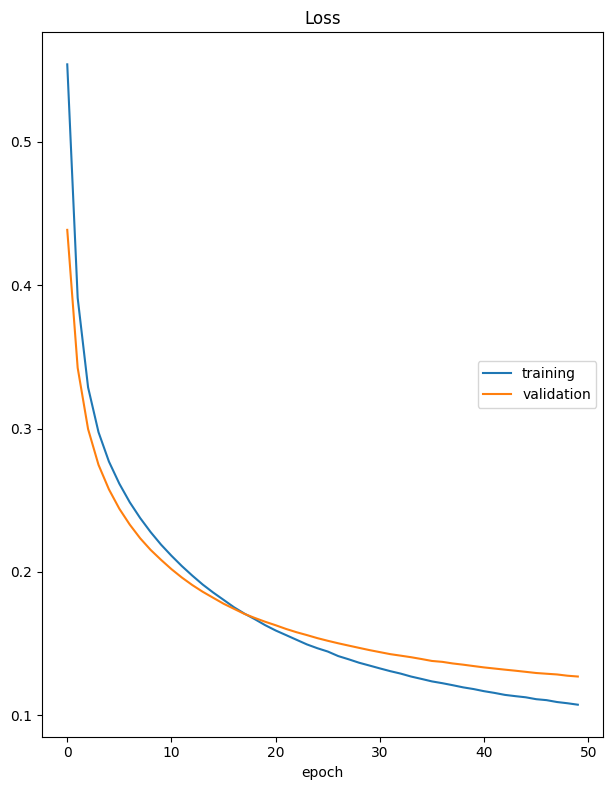

Loss
	training         	 (min:    0.107, max:    0.554, cur:    0.107)
	validation       	 (min:    0.127, max:    0.439, cur:    0.127)


In [8]:
train_dataset = PromptIDataset('/content/drive/MyDrive/SQLShieldOnly.csv')
validation_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_val.csv')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)

epochs = 50
learning_rate = 1e-5
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model[2].parameters(), lr=learning_rate)

output_path = pathlib.Path("/content/drive/MyDrive/classifier_output/best_ood_model.pth")
output_path.parent.mkdir(exist_ok=True)

trained_model = train_model(model, loss_function, optimizer,
                            train_loader, val_loader,
                            device=device, epochs=epochs, output_path=output_path)

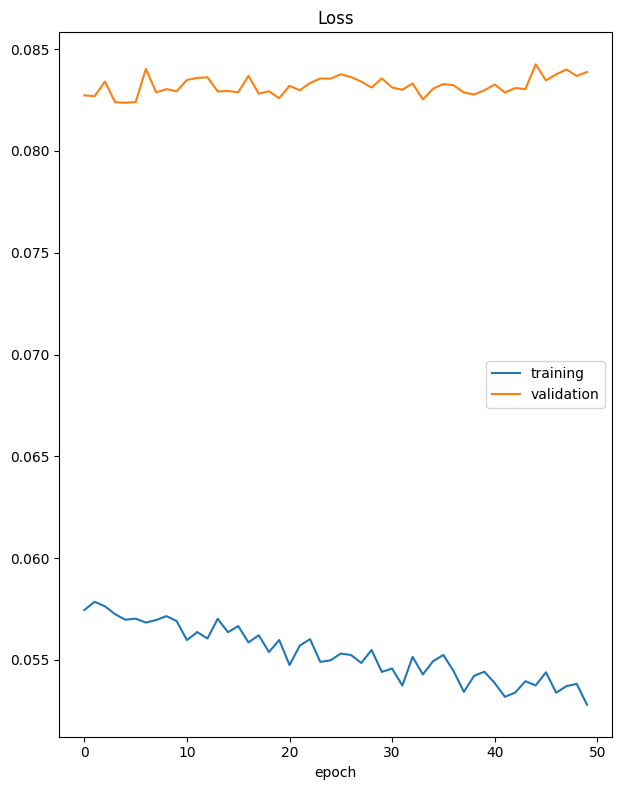

Loss
	training         	 (min:    0.053, max:    0.058, cur:    0.053)
	validation       	 (min:    0.082, max:    0.084, cur:    0.084)


In [ ]:
train_dataset = PromptIDataset('/content/drive/MyDrive/SQLShieldOnly.csv')
validation_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_val.csv')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)

epochs = 50
learning_rate = 1e-5
loss_function = nn.BCEWithLogitsLoss()
optimizer_two = torch.optim.Adam(model_two[2].parameters(), lr=learning_rate)

output_path = pathlib.Path("/content/drive/MyDrive/classifier_output/best_ood_model_two.pth")
output_path.parent.mkdir(exist_ok=True)

trained_model = train_model(model_two, loss_function, optimizer_two,
                            train_loader, val_loader,
                            device=device, epochs=epochs, output_path=output_path)

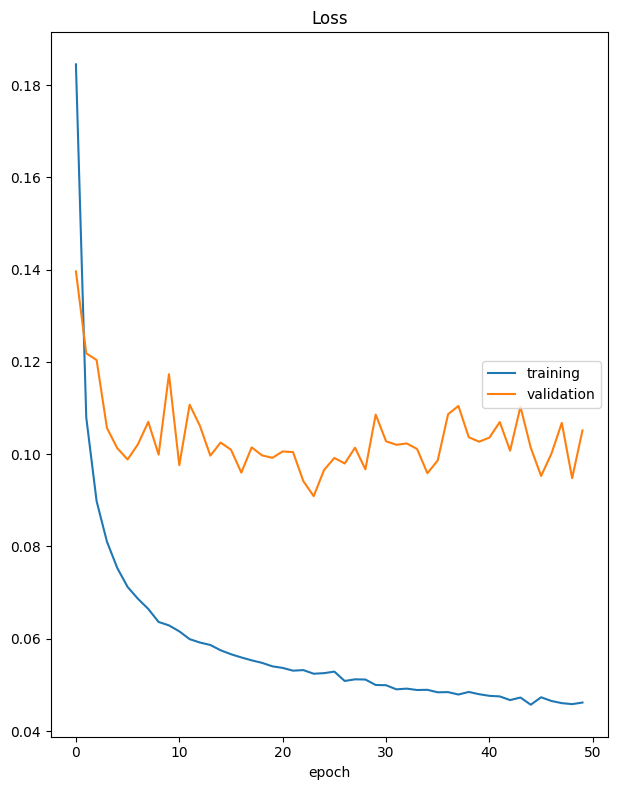

Loss
	training         	 (min:    0.046, max:    0.184, cur:    0.046)
	validation       	 (min:    0.091, max:    0.140, cur:    0.105)


In [ ]:
train_dataset = PromptIDataset('/content/drive/MyDrive/SQLShieldOnly.csv')
validation_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_val.csv')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)

epochs = 50
learning_rate = 1e-5
loss_function = nn.BCEWithLogitsLoss()
optimizer_three = torch.optim.Adam(model_three[2].parameters(), lr=learning_rate)

output_path = pathlib.Path("/content/drive/MyDrive/classifier_output/best_ood_model_three.pth")
output_path.parent.mkdir(exist_ok=True)

trained_model = train_model(model_three, loss_function, optimizer_three,
                            train_loader, val_loader,
                            device=device, epochs=epochs, output_path=output_path)

In [8]:
import random
def few_shot_sample(dataset, num_samples_per_class=5, seed=42):
    random.seed(seed)
    class_samples = {0: [],  # Class 0 samples
                     1: [],  # Class 1 samples
                     2: [],  # Class 2 samples
                     3: [],  # Class 3 samples
                     4: [],  # Class 4 samples
                     5: []}  
    
    #If a row has 0 for all five classes, it is class 5
    labels = dataset.dataframe.iloc[:, 1:].values
    for idx, label in enumerate(labels):
        if np.sum(label) == 0:
            class_samples[5].append(idx)
        else:
            for class_idx in range(5):
                if label[class_idx] == 1:
                    class_samples[class_idx].append(idx)
                    break
    
    few_shot_indices = []
    for class_idx, indices in class_samples.items():
        if len(indices) > num_samples_per_class:
            few_shot_indices.extend(random.sample(indices, num_samples_per_class))
        else:
            few_shot_indices.extend(indices)
    few_shot_subset = torch.utils.data.Subset(dataset, few_shot_indices)
    return few_shot_subset

In [11]:
#build nearest centroid classifier using the few-shot samples
import random
shots = [1, 2, 4, 8]
train_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_train.csv')
validation_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_val.csv')
pure_model = SentenceTransformer(og_model_name)
pure_model.to(device)
runs = 500
overall_results = {}
for run in range(runs):
    new_seed = random.randint(0, 10000)
    for shot in shots:
        few_shot_subset = few_shot_sample(train_dataset, num_samples_per_class=shot, seed=new_seed)
        few_shot_loader = DataLoader(few_shot_subset, batch_size=16, shuffle=False)
        
        classes = {0: [], 1: [], 2: [], 3: [], 4: [], 5: []}
        with torch.no_grad():
            for texts, labels in few_shot_loader:
                inputs = pure_model.tokenize(list(texts))
                inputs = {key: val.to(device) for key, val in inputs.items()}
                embeddings = pure_model(inputs)['sentence_embedding']
                for i in range(len(labels)):
                    label = labels[i].cpu().numpy()
                    if np.sum(label) == 0:
                        classes[5].append(embeddings[i].cpu().numpy())
                    else:
                        for class_idx in range(5):
                            if label[class_idx] == 1:
                                classes[class_idx].append(embeddings[i].cpu().numpy())
                                break
        centroids = {class_idx: np.mean(embeddings, axis=0) for class_idx, embeddings in classes.items()}

        # Evaluate on validation set
        val_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)
        correct = 0
        total = 0
        with torch.no_grad():
            for texts, labels in val_loader:
                inputs = pure_model.tokenize(list(texts))
                inputs = {key: val.to(device) for key, val in inputs.items()}
                embeddings = pure_model(inputs)['sentence_embedding'].cpu().numpy()
                for i in range(len(labels)):
                    label = labels[i].cpu().numpy()
                    if np.sum(label) == 0:
                        true_class = 5
                    else:
                        true_class = np.where(label == 1)[0][0]
                    
                    distances = {class_idx: np.linalg.norm(embeddings[i] - centroid) for class_idx, centroid in centroids.items()}
                    predicted_class = min(distances, key=distances.get)
                    
                    if predicted_class == true_class:
                        correct += 1
                    total += 1
        accuracy = correct / total
        print(f"Shot: {shot}, Accuracy: {accuracy:.4f}")
        overall_results[(shot, run)] = accuracy

#print overall average results
for shot in shots:
    accuracies = [overall_results[(shot, run)] for run in range(runs)]
    avg_accuracy = sum(accuracies) / len(accuracies)
    print(f"Shot: {shot}, Average Accuracy over {runs} runs: {avg_accuracy:.4f}")

In [14]:
#plot line graph of average accuracy vs shots with a baseline accuracy line at 16.67%
import matplotlib.pyplot as plt
avg_accuracies = []
for shot in shots:
    accuracies = [overall_results[(shot, run)] for run in range(runs)]
    avg_accuracy = sum(accuracies) / len(accuracies)
    avg_accuracies.append(avg_accuracy)
plt.figure(figsize=(10, 6))
plt.plot(shots, avg_accuracies, marker='o', label='Few-Shot Accuracy')
plt.axhline(y=0.1667, color='r', linestyle='--', label='Baseline Accuracy (16.67%)')
plt.xlabel('Number of Shots')
plt.ylabel('Average Accuracy')
plt.xticks(shots)
plt.grid()
plt.legend()
plt.show()

In [11]:
test_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_test.csv')
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']

#if model predicts 0 for all classes, then it is predicting benign, otherwise it is predicting the class with the highest logit
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        texts, labels = batch

        inputs = model.tokenize(texts)
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.float().to(device) # Assuming shape is (batch_size, 5)

        outputs = model(inputs)
        logits = outputs['sentence_embedding']
        
        # --- PREDICTIONS LOGIC ---
        probs = torch.sigmoid(logits) 
        threshold = 0.35
        mask = (probs > threshold).any(dim=1)
        preds = torch.where(mask, torch.argmax(probs, dim=1), torch.tensor(5).to(device))
        
        all_preds.extend(preds.cpu().numpy())

        # --- CORRECTED ACTUAL LABELS LOGIC ---
        # If the max value in the label row is 0, it's Benign. Otherwise, take the argmax.
        label_mask = (labels > 0).any(dim=1) 
        actuals = torch.where(label_mask, torch.argmax(labels, dim=1), torch.tensor(5).to(device))
        
        all_labels.extend(actuals.cpu().numpy())

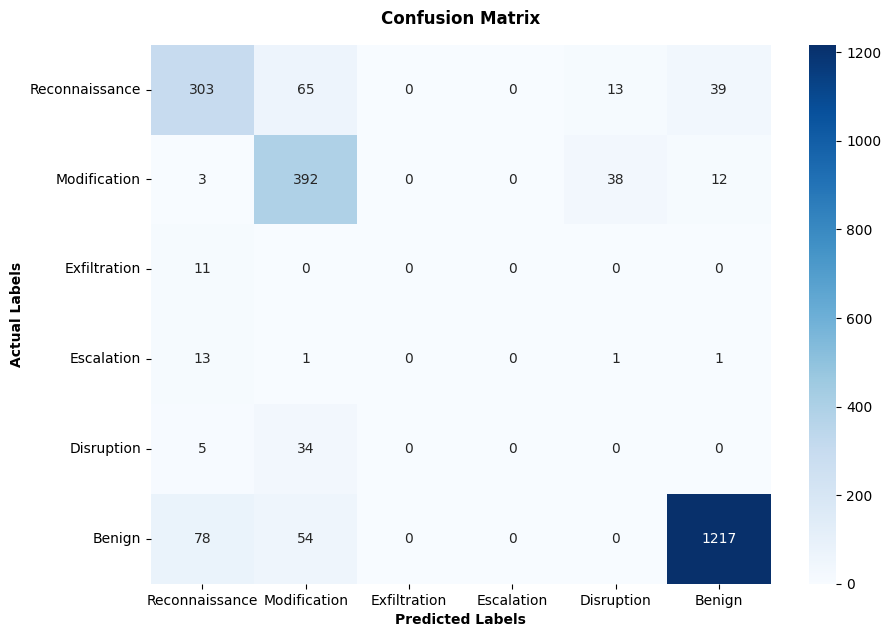

                precision    recall  f1-score   support

Reconnaissance       0.73      0.72      0.73       420
  Modification       0.72      0.88      0.79       445
  Exfiltration       0.00      0.00      0.00        11
    Escalation       0.00      0.00      0.00        16
    Disruption       0.00      0.00      0.00        39
        Benign       0.96      0.90      0.93      1349

      accuracy                           0.84      2280
     macro avg       0.40      0.42      0.41      2280
  weighted avg       0.84      0.84      0.84      2280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']

# Generate the raw matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4, 5])

# Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels', fontweight='bold')
plt.ylabel('Actual Labels', fontweight='bold')
plt.title('Confusion Matrix', fontweight='bold', pad=15)
plt.show()

#Calculate precision, recall, and F1-score for each class
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=classes))

In [12]:
from sklearn.metrics import roc_auc_score

classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']

model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        texts, labels = batch

        inputs = model.tokenize(texts)
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.float().to(device) # Shape: (batch_size, 5)

        outputs = model(inputs)
        logits = outputs['sentence_embedding']
        
        # Get probabilities for the 5 malicious classes
        probs = torch.sigmoid(logits) 

        # --- DERIVE THE BENIGN CLASS (Index 5) ---
        # Actual Benign: 1.0 if all 5 malicious labels are 0, else 0.0
        benign_actual = (labels.max(dim=1)[0] == 0).float().unsqueeze(1)
        
        # Predicted Benign Prob: 1.0 minus the highest malicious probability
        benign_prob = (1.0 - probs.max(dim=1)[0]).unsqueeze(1)

        # Concatenate them to make full (batch_size, 6) arrays
        full_labels = torch.cat([labels, benign_actual], dim=1)
        full_probs = torch.cat([probs, benign_prob], dim=1)

        all_labels.append(full_labels.cpu().numpy())
        all_probs.append(full_probs.cpu().numpy())

# Stack batches into single NumPy arrays
all_labels = np.vstack(all_labels)
all_probs = np.vstack(all_probs)

# --- CALCULATE ROC-AUC ---
print("--- ROC-AUC Scores per Class ---")
for i, class_name in enumerate(classes):
    try:
        # Calculate AUC for this specific class vs the rest
        auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
        print(f"{class_name:>15}: {auc:.4f}")
    except ValueError:
        # This triggers if a class somehow has 0 actual samples in the test set
        print(f"{class_name:>15}: N/A (No positive samples in true labels)")

# Calculate the Macro Average across all 6 classes
try:
    macro_auc = roc_auc_score(all_labels, all_probs, average='macro')
    print("-" * 32)
    print(f"{'Macro Average':>15}: {macro_auc:.4f}")
except ValueError:
    pass

# Calculate individual thresholds for each class based on the ROC curve for the training set, then apply those thresholds to the test set to get binary predictions and recalculate metrics
train_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_train.csv')
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)

with torch.no_grad():
    all_train_labels = []
    all_train_probs = []
    for batch in train_loader:
        texts, labels = batch

        inputs = model.tokenize(texts)
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.float().to(device)

        outputs = model(inputs)
        logits = outputs['sentence_embedding']
        
        probs = torch.sigmoid(logits) 

        benign_actual = (labels.max(dim=1)[0] == 0).float().unsqueeze(1)
        benign_prob = (1.0 - probs.max(dim=1)[0]).unsqueeze(1)

        full_labels = torch.cat([labels, benign_actual], dim=1)
        full_probs = torch.cat([probs, benign_prob], dim=1)

        all_train_labels.append(full_labels.cpu().numpy())
        all_train_probs.append(full_probs.cpu().numpy())
all_train_labels = np.vstack(all_train_labels)
all_train_probs = np.vstack(all_train_probs)
from sklearn.metrics import roc_curve
optimal_thresholds = []
for i in range(all_train_labels.shape[1]):
    fpr, tpr, thresholds = roc_curve(all_train_labels[:, i], all_train_probs[:, i])
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    optimal_thresholds.append(optimal_threshold)
    print(f"Optimal threshold for class {classes[i]}: {optimal_threshold:.4f}")

--- ROC-AUC Scores per Class ---
 Reconnaissance: 0.9205
   Modification: 0.9696
   Exfiltration: 0.9043
     Escalation: 0.8780
     Disruption: 0.9770
         Benign: 0.9661
--------------------------------
  Macro Average: 0.9359
Optimal threshold for class Reconnaissance: 0.2418
Optimal threshold for class Modification: 0.3634
Optimal threshold for class Exfiltration: 0.0172
Optimal threshold for class Escalation: 0.0221
Optimal threshold for class Disruption: 0.2624
Optimal threshold for class Benign: 0.6834


In [13]:
small_test_file_name = '/content/drive/MyDrive/gemini_predicted_375.csv'
#The small test set has the first column as a class label and the second column as the text.
classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']

class smallDataset(Dataset):
    def __init__(self, csv_file):
        self.dataframe = pd.read_csv(csv_file)
        self.texts = self.dataframe['text'].tolist()
        self.labels = self.dataframe['Predicted_Class_Index'].astype(int).tolist()

    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        return text, label

num_correct = 0
num_total = 0
model.eval()

# Use the dataset class correctly
test_ds = smallDataset(small_test_file_name)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

with torch.no_grad(): # Essential for evaluation to save memory
    for texts, labels in test_loader:
        labels = labels.to(device)
        inputs = model.tokenize(list(texts))
        inputs = {key: val.to(device) for key, val in inputs.items()}
        
        outputs = model(inputs)
        logits = outputs['sentence_embedding']
        probs = torch.sigmoid(logits)
        batch_correct = 0

        for i in range(probs.shape[0]):
            true_label = labels[i].item()
            
            # 1. Handle the Malicious Classes (0-4)
            if true_label < 5:
                # Check if the specific true class probability is above its threshold
                if probs[i, true_label] > optimal_thresholds[true_label]:
                    batch_correct += 1
                    
            # 2. Handle the Benign Class (5)
            else:
                # Benign is correct if NO malicious thresholds were met
                is_malicious = False
                for class_idx in range(5):
                    if probs[i, class_idx] > optimal_thresholds[class_idx]:
                        is_malicious = True
                        break
                if not is_malicious:
                    batch_correct += 1

        num_correct += batch_correct
        num_total += labels.size(0)

accuracy = num_correct / num_total
print(f"Accuracy on small test set: {accuracy:.4f}")

Accuracy on small test set: 0.8640


In [ ]:
#ROC-AUC on the small test set
all_labels = []
all_probs = []
with torch.no_grad():
    for texts, labels in test_loader:
        labels = labels.to(device)
        inputs = model.tokenize(list(texts))
        inputs = {key: val.to(device) for key, val in inputs.items()}
        
        outputs = model(inputs)
        logits = outputs['sentence_embedding']
        probs = torch.sigmoid(logits)

        #benign probability calculation
        benign_prob = (1.0 - probs.max(dim=1)[0]).unsqueeze(1)
        full_probs = torch.cat([probs, benign_prob], dim=1)
        
        all_labels.append(labels.cpu().numpy())
        all_probs.append(full_probs.cpu().numpy())
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)
print("--- ROC-AUC Scores per Class on Small Test Set ---")
for i, class_name in enumerate(classes):
    try:
        auc = roc_auc_score((all_labels == i).astype(int), all_probs[:, i])
        print(f"{class_name:>15}: {auc:.4f}")
    except ValueError:
        print(f"{class_name:>15}: N/A (No positive samples in true labels)")
#Macro Average
try:
    macro_auc = roc_auc_score(all_labels, all_probs, average='macro')
    print("-" * 32)
    print(f"{'Macro Average':>15}: {macro_auc:.4f}")
except ValueError:
    print("Macro Average: N/A (Issue with true labels or probabilities)")

--- ROC-AUC Scores per Class on Small Test Set ---
 Reconnaissance: 0.9292
   Modification: 0.9698
   Exfiltration: 0.9148
     Escalation: nan
     Disruption: 0.9115
         Benign: 0.9913
Macro Average: N/A (Issue with true labels or probabilities)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [20]:
#Apply the new threshold to the new dataset and get a new confusion matrix
imba_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_imba_data.csv')
imba_loader = DataLoader(imba_dataset, batch_size=16, shuffle=False)

with torch.no_grad():
    all_labels = []
    all_preds = []
    for batch in imba_loader:
        texts, labels = batch

        inputs = model.tokenize(texts)
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.float().to(device) # Shape: (batch_size, 5)

        outputs = model(inputs)
        logits = outputs['sentence_embedding']
        
        # Get probabilities for the 5 malicious classes
        probs = torch.sigmoid(logits) 

        # --- DERIVE THE BENIGN CLASS (Index 5) ---
        benign_actual = (labels.max(dim=1)[0] == 0).float().unsqueeze(1)
        
        # Apply class-specific thresholds to get predicted labels
        predicted_labels = torch.zeros_like(labels)
        for i, class_name in enumerate(classes[:-1]):  # Skip Benign for now
            predicted_labels[:, i] = (probs[:, i] > optimal_thresholds[i]).float()
        
        # Determine predicted Benign based on the absence of any malicious predictions
        predicted_benign = (predicted_labels.sum(dim=1) == 0).float().unsqueeze(1)
        
        # Combine predictions and actuals
        full_preds = torch.cat([predicted_labels, predicted_benign], dim=1)
        full_labels = torch.cat([labels, benign_actual], dim=1)

        all_preds.append(full_preds.cpu().numpy())
        all_labels.append(full_labels.cpu().numpy())
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
cm = confusion_matrix(all_labels.argmax(axis=1), all_preds.argmax(axis=1), labels=[0, 1, 2, 3, 4, 5])
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels', fontweight='bold')
plt.ylabel('Actual Labels', fontweight='bold')
plt.show()

In [13]:
#calculate and plot the macro average ROC AUC scores for each class on the imbalanced dataset
classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']

for i, class_name in enumerate(classes):
    try:
        auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
        print(f"{class_name:>15}: {auc:.4f}")
    except ValueError:
        print(f"{class_name:>15}: N/A (No positive samples in true labels)")
#calculate macro average ROC AUC score
try:
    macro_auc = roc_auc_score(all_labels, all_preds, average='macro')
    print("-" * 32)
    print(f"{'Macro Average':>15}: {macro_auc:.4f}")
except ValueError:
    pass

#plot the ROC curve for each class on the imbalanced dataset
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 7))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
#legend with larger font and bold
plt.legend(loc='lower right', fontsize=12)
plt.show()

TypeError: list indices must be integers or slices, not tuple

In [27]:
#Run the original model with the imba dataset and output the embeddings
pure_model = SentenceTransformer(og_model_name)
pure_model.to(device)
imba_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_imba_data.csv')
imba_loader = DataLoader(imba_dataset, batch_size=16, shuffle=False)

embeddings = []
labels = []
with torch.no_grad():
    for texts, label in imba_loader:
        inputs = pure_model.tokenize(list(texts))
        inputs = {key: val.to(device) for key, val in inputs.items()}
        embedding = pure_model(inputs)['sentence_embedding']
        embeddings.append(embedding.cpu().numpy())
        labels.append(label.cpu().numpy())
embeddings = np.vstack(embeddings)
labels = np.vstack(labels)

In [28]:
import numpy as np
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

# 1. Convert your list of embeddings into a NumPy array
# Assuming 'embeddings' is your pre-existing list of vectors
X = np.array(embeddings)

# 2. Apply PCA
# Reducing to 50 dimensions is the standard sweet spot for text embeddings
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(X)

print(f"Shape after PCA: {embeddings_pca.shape}")

# 3. Apply UMAP
# Note: metric='cosine' is strongly recommended because BGE models 
# are trained and optimized using cosine similarity.
reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=15,    # Adjust this to balance local vs global structure
    min_dist=0.1,      # How tightly packed the points should be
    metric='cosine', 
    random_state=42    # For reproducibility
)

embeddings_umap = reducer.fit_transform(embeddings_pca)
print(f"Shape after UMAP: {embeddings_umap.shape}")

# 4. Visualize the results
plt.figure(figsize=(10, 8))
plt.scatter(
    embeddings_umap[:, 0], 
    embeddings_umap[:, 1], 
    s=5,           # Dot size
    alpha=0.6,     # Transparency
    cmap='Spectral'
)
plt.title('PCA + UMAP Projection of BGE Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# the labels are a 5d vector. But if all five values are 0, then it is actually class 6 (benign). So we need to convert the 5d vector into a single integer label from 0 to 5, where 5 represents the benign class.
class_indices = np.argmax(labels, axis=1)
class_indices = np.where(np.all(labels == 0, axis=1), 5, class_indices)
classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'black']
plt.figure(figsize=(10, 8))
#Make very distinct colors for each class
scatter = plt.scatter(
    embeddings_umap[:, 0], 
    embeddings_umap[:, 1], 
    c=class_indices, 
    s=5,           # Dot size
    alpha=0.6,     # Transparency
    cmap=plt.matplotlib.colors.ListedColormap(colors)
)
plt.legend(handles=scatter.legend_elements()[0], labels=classes, loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
import umap

y = class_indices

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)

# ---------------------------------------------------------
# 2. Supervised UMAP: Metric Learning
# ---------------------------------------------------------
# By passing 'y' into fit_transform, UMAP operates in supervised mode. 
# It will use the labels to pull points of the same class closer together 
# and push different classes further apart.
umap_model = umap.UMAP(
    n_neighbors=15,     # Balance between local and global structure
    min_dist=0.1,       # How tightly packed the points are
    n_components=2,     # Number of output dimensions (2 or 3 is best for plotting)
    metric='euclidean',
    random_state=42
)

# Crucial step: pass 'y' to supervise the manifold learning
X_umap = umap_model.fit_transform(X_pca, y=y)

In [39]:
#visualize the results
import matplotlib.pyplot as plt
classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_umap[:, 0], 
    X_umap[:, 1], 
    c=class_indices, 
    s=5,           # Dot size
    alpha=0.6,     # Transparency
    cmap=plt.matplotlib.colors.ListedColormap(colors)
)
plt.legend(handles=scatter.legend_elements()[0], labels=classes, loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
from transformers import pipeline

sql_query_shield = pipeline("text-classification", model="salmane11/SQLQueryShield")

sql_shield_classes = ["MALICIOUS", "SAFE"]

#run the sql query shield on the imbalanced dataset and get the predictions
imba_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_test.csv')
imba_loader = DataLoader(imba_dataset, batch_size=16, shuffle=False)
sql_shield_preds = []
with torch.no_grad():
    for texts, labels in imba_loader:
        for text in texts:
            result = sql_query_shield(text)[0]
            sql_shield_preds.append(result['label'])

#If the label is MALICIOUS, convert to 1, if SAFE, convert to 0
sql_shield_preds = [1 if label == "MALICIOUS" else 0 for label in sql_shield_preds]

#if the original label from the imbalanced dataset is all zeros, then it is benign, otherwise it is malicious
imba_labels = []
for labels in imba_loader.dataset.labels:
    if np.sum(labels) == 0:
        imba_labels.append(0) #benign
    else:
        imba_labels.append(1) #malicious
#calculate the accuracy of the sql query shield on the imbalanced dataset
correct = 0
total = 0
for pred, label in zip(sql_shield_preds, imba_labels):
    if pred == label:
        correct += 1
    total += 1

accuracy = correct / total
print(f"SQL Query Shield Accuracy on Imbalanced Dataset: {accuracy:.4f}")

sql_prompt_shield = pipeline("text-classification", model="salmane11/SQLPromptShield")

sql_prompt_shield_classes = ["MALICIOUS", "SAFE"]

with torch.no_grad():
    sql_prompt_shield_preds = []
    for texts, labels in imba_loader:
        for text in texts:
            result = sql_prompt_shield(text)[0]
            sql_prompt_shield_preds.append(result['label'])
sql_prompt_shield_preds = [1 if label == "MALICIOUS" else 0 for label in sql_prompt_shield_preds]
correct = 0
total = 0
for pred, label in zip(sql_prompt_shield_preds, imba_labels):
    if pred == label:
        correct += 1
    total += 1
accuracy = correct / total
print(f"SQL Prompt Shield Accuracy on Imbalanced Dataset: {accuracy:.4f}")


config.json:   0%|          | 0.00/883 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

SQL Prompt Shield Accuracy on Imbalanced Dataset: 0.9425


In [11]:
#calculate f1 score for both shields
from sklearn.metrics import f1_score
sql_query_shield_f1 = f1_score(imba_labels, sql_shield_preds)
sql_prompt_shield_f1 = f1_score(imba_labels, sql_prompt_shield_preds)
print(f"SQL Query Shield F1 Score: {sql_query_shield_f1:.4f}")
print(f"SQL Prompt Shield F1 Score: {sql_prompt_shield_f1:.4f}")
#print recall and precision for both shields
from sklearn.metrics import precision_score, recall_score
sql_query_shield_precision = precision_score(imba_labels, sql_shield_preds)
sql_query_shield_recall = recall_score(imba_labels, sql_shield_preds)
sql_prompt_shield_precision = precision_score(imba_labels, sql_prompt_shield_preds)
sql_prompt_shield_recall = recall_score(imba_labels, sql_prompt_shield_preds)
print(f"SQL Query Shield Precision: {sql_query_shield_precision:.4f}")
print(f"SQL Query Shield Recall: {sql_query_shield_recall:.4f}")
print(f"SQL Prompt Shield Precision: {sql_prompt_shield_precision:.4f}")
print(f"SQL Prompt Shield Recall: {sql_prompt_shield_recall:.4f}")

SQL Query Shield F1 Score: 0.6506
SQL Prompt Shield F1 Score: 0.9340
SQL Query Shield Precision: 0.4821
SQL Query Shield Recall: 1.0000
SQL Prompt Shield Precision: 0.8795
SQL Prompt Shield Recall: 0.9957


In [22]:
test_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_test.csv')
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        texts, labels = batch

        inputs = model.tokenize(texts)
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.float().to(device) # Assuming shape is (batch_size, 5)

        outputs = model(inputs)
        logits = outputs['sentence_embedding']
        
        probs = torch.sigmoid(logits) 
        threshold = 0.35
        mask = (probs > threshold).any(dim=1)
        preds = torch.where(mask, torch.argmax(probs, dim=1), torch.tensor(5).to(device))
        
        all_preds.extend(preds.cpu().numpy())

        label_mask = (labels > 0).any(dim=1) 
        actuals = torch.where(label_mask, torch.argmax(labels, dim=1), torch.tensor(5).to(device))
        
        all_labels.extend(actuals.cpu().numpy())
from sklearn.metrics import classification_report
classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']
print(classification_report(all_labels, all_preds, target_names=classes))

                precision    recall  f1-score   support

Reconnaissance       0.71      0.78      0.74       420
  Modification       0.81      0.90      0.86       445
  Exfiltration       0.00      0.00      0.00        11
    Escalation       0.22      0.12      0.16        16
    Disruption       0.11      0.18      0.14        39
        Benign       0.97      0.90      0.94      1349

      accuracy                           0.86      2280
     macro avg       0.47      0.48      0.47      2280
  weighted avg       0.87      0.86      0.86      2280



In [23]:
test_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_test.csv')
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
model_two.eval()
all_labels_two = []
all_preds_two = []
with torch.no_grad():
    for batch in test_loader:
        texts, labels = batch

        inputs = model_two.tokenize(texts)
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.float().to(device) # Assuming shape is (batch_size, 5)

        outputs = model_two(inputs)
        logits = outputs['sentence_embedding']
        
        probs = torch.sigmoid(logits) 
        threshold = 0.35
        mask = (probs > threshold).any(dim=1)
        preds = torch.where(mask, torch.argmax(probs, dim=1), torch.tensor(5).to(device))
        
        all_preds_two.extend(preds.cpu().numpy())

        label_mask = (labels > 0).any(dim=1) 
        actuals = torch.where(label_mask, torch.argmax(labels, dim=1), torch.tensor(5).to(device))
        
        all_labels_two.extend(actuals.cpu().numpy())
from sklearn.metrics import classification_report
classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']
print(classification_report(all_labels_two, all_preds_two, target_names=classes))

                precision    recall  f1-score   support

Reconnaissance       0.73      0.83      0.78       420
  Modification       0.90      0.87      0.88       445
  Exfiltration       0.11      0.09      0.10        11
    Escalation       0.25      0.06      0.10        16
    Disruption       0.21      0.38      0.27        39
        Benign       0.96      0.91      0.93      1349

      accuracy                           0.87      2280
     macro avg       0.53      0.53      0.51      2280
  weighted avg       0.88      0.87      0.87      2280



In [24]:
test_dataset = PromptIDataset('/content/drive/MyDrive/gemini_labelled_test.csv')
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
model_three.eval()
all_labels_three = []
all_preds_three = []
with torch.no_grad():
    for batch in test_loader:
        texts, labels = batch

        inputs = model_three.tokenize(texts)
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.float().to(device) # Assuming shape is (batch_size, 5)

        outputs = model_three(inputs)
        logits = outputs['sentence_embedding']
        
        probs = torch.sigmoid(logits) 
        threshold = 0.35
        mask = (probs > threshold).any(dim=1)
        preds = torch.where(mask, torch.argmax(probs, dim=1), torch.tensor(5).to(device))
        
        all_preds_three.extend(preds.cpu().numpy())

        label_mask = (labels > 0).any(dim=1) 
        actuals = torch.where(label_mask, torch.argmax(labels, dim=1), torch.tensor(5).to(device))
        
        all_labels_three.extend(actuals.cpu().numpy())
from sklearn.metrics import classification_report
classes = ['Reconnaissance', 'Modification', 'Exfiltration', 'Escalation', 'Disruption', 'Benign']
print(classification_report(all_labels_three, all_preds_three, target_names=classes))

                precision    recall  f1-score   support

Reconnaissance       0.73      0.79      0.76       420
  Modification       0.81      0.89      0.85       445
  Exfiltration       0.09      0.09      0.09        11
    Escalation       0.50      0.12      0.20        16
    Disruption       0.12      0.21      0.15        39
        Benign       0.98      0.91      0.94      1349

      accuracy                           0.86      2280
     macro avg       0.54      0.50      0.50      2280
  weighted avg       0.88      0.86      0.87      2280



In [25]:
#calculate my f1 score, if you convert my predictions to binary using the same logic as the sql shields (if any of the five classes is predicted, then it is malicious, otherwise it is benign)
my_preds_binary = [1 if pred != 5 else 0 for pred in all_preds]
my_labels_binary = [1 if label != 5 else 0 for label in all_labels]
my_f1 = f1_score(my_labels_binary, my_preds_binary)
my_f1_two = f1_score([1 if label != 5 else 0 for label in all_labels_two], [1 if pred != 5 else 0 for pred in all_preds_two])
my_f1_three = f1_score([1 if label != 5 else 0 for label in all_labels_three], [1 if pred != 5 else 0 for pred in all_preds_three])
print(f"My Model F1 Score (Binary): {my_f1:.4f}")
print(f"Model Two F1 Score (Binary): {my_f1_two:.4f}")
print(f"Model Three F1 Score (Binary): {my_f1_three:.4f}")
my_recall = recall_score(my_labels_binary, my_preds_binary)
my_precision = precision_score(my_labels_binary, my_preds_binary)
my_recall_two = recall_score([1 if label != 5 else 0 for label in all_labels_two], [1 if pred != 5 else 0 for pred in all_preds_two])
my_precision_two = precision_score([1 if label != 5 else 0 for label in all_labels_two], [1 if pred != 5 else 0 for pred in all_preds_two])
my_recall_three = recall_score([1 if label != 5 else 0 for label in all_labels_three], [1 if pred != 5 else 0 for pred in all_preds_three])
my_precision_three = precision_score([1 if label != 5 else 0 for label in all_labels_three], [1 if pred != 5 else 0 for pred in all_preds_three])
print(f"My Model Precision (Binary): {my_precision:.4f}")
print(f"My Model Recall (Binary): {my_recall:.4f}")
print(f"Model Two Precision (Binary): {my_precision_two:.4f}")
print(f"Model Two Recall (Binary): {my_recall_two:.4f}")
print(f"Model Three Precision (Binary): {my_precision_three:.4f}")

My Model F1 Score (Binary): 0.9149
Model Two F1 Score (Binary): 0.9103
Model Three F1 Score (Binary): 0.9207
My Model Precision (Binary): 0.8702
My Model Recall (Binary): 0.9646
Model Two Precision (Binary): 0.8798
Model Two Recall (Binary): 0.9431
Model Three Precision (Binary): 0.8789


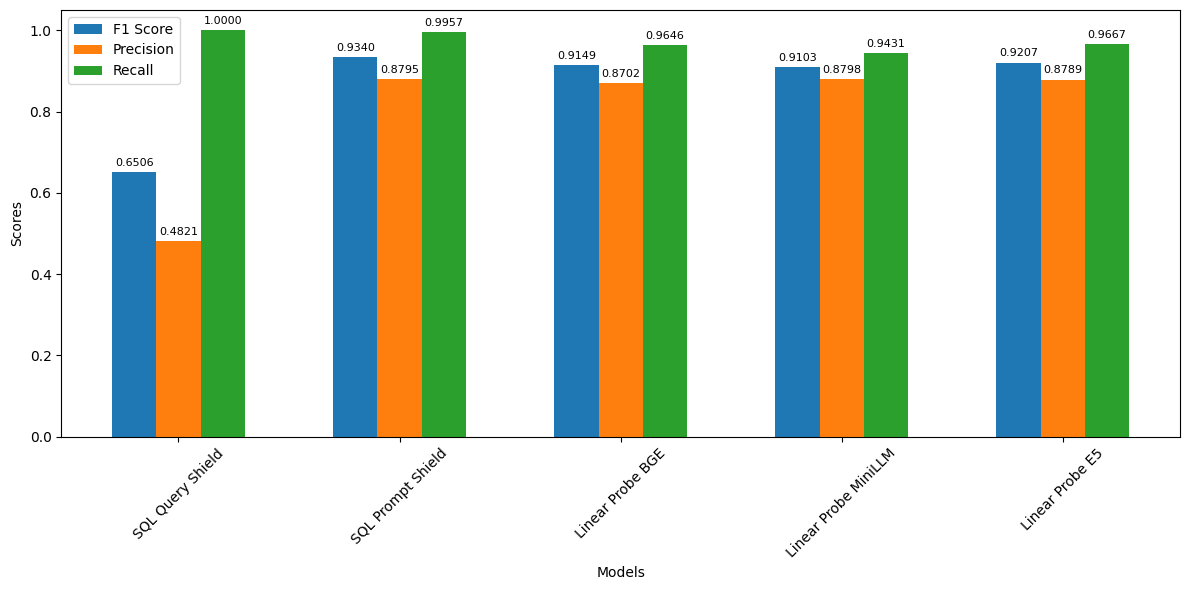

In [26]:
#plot a bar chart with f1, precision, and recall for all five models (sql query shield, sql prompt shield, and my three models)
import matplotlib.pyplot as plt
import numpy as np
labels = ['SQL Query Shield', 'SQL Prompt Shield', 'Linear Probe BGE', 'Linear Probe MiniLLM', 'Linear Probe E5']
f1_scores = [sql_query_shield_f1, sql_prompt_shield_f1, my_f1, my_f1_two, my_f1_three]
precision_scores = [sql_query_shield_precision, sql_prompt_shield_precision, my_precision, my_precision_two, my_precision_three]
recall_scores = [sql_query_shield_recall, sql_prompt_shield_recall, my_recall, my_recall_two, my_recall_three]
x = np.arange(len(labels))
width = 0.2
#add value labels on top of each bar
plt.figure(figsize=(12, 6))
plt.bar(x - width, f1_scores, width, label='F1 Score')
plt.bar(x, precision_scores, width, label='Precision')
plt.bar(x + width, recall_scores, width, label='Recall')
for i in range(len(labels)):
    plt.text(x[i] - width, f1_scores[i] + 0.01, f"{f1_scores[i]:.4f}", ha='center', va='bottom', fontsize=8)
    plt.text(x[i], precision_scores[i] + 0.01, f"{precision_scores[i]:.4f}", ha='center', va='bottom', fontsize=8)
    plt.text(x[i] + width, recall_scores[i] + 0.01, f"{recall_scores[i]:.4f}", ha='center', va='bottom', fontsize=8)
plt.xlabel('Models')
plt.ylabel('Scores')
plt.xticks(x, labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
#Try prompt shield on SQLShieldOnly
sql_prompt_shield_preds_train = []
sql_shield_dataset = PromptIDataset('/content/drive/MyDrive/SQLShieldOnly.csv')
sql_shield_loader = DataLoader(sql_shield_dataset, batch_size=16, shuffle=False)
with torch.no_grad():
    for texts, labels in sql_shield_loader:
        for text in texts:
            result = sql_prompt_shield(text)[0]
            sql_prompt_shield_preds_train.append(result['label'])
sql_prompt_shield_preds_train = [1 if label == "MALICIOUS" else 0 for label in sql_prompt_shield_preds_train]
sql_shield_labels_train = []
for labels in sql_shield_loader.dataset.labels:
    if np.sum(labels) == 0:
        sql_shield_labels_train.append(0) #benign
    else:
        sql_shield_labels_train.append(1) #malicious
sql_prompt_shield_f1_train = f1_score(sql_shield_labels_train, sql_prompt_shield_preds_train)
sql_prompt_shield_precision_train = precision_score(sql_shield_labels_train, sql_prompt_shield_preds_train)
sql_prompt_shield_recall_train = recall_score(sql_shield_labels_train, sql_prompt_shield_preds_train)
print(f"SQL Prompt Shield F1 Score on SQLShieldOnly: {sql_prompt_shield_f1_train:.4f}")
print(f"SQL Prompt Shield Precision on SQLShieldOnly: {sql_prompt_shield_precision_train:.4f}")
print(f"SQL Prompt Shield Recall on SQLShieldOnly: {sql_prompt_shield_recall_train:.4f}")

SQL Prompt Shield F1 Score on SQLShieldOnly: 0.9780
SQL Prompt Shield Precision on SQLShieldOnly: 0.9572
SQL Prompt Shield Recall on SQLShieldOnly: 0.9997


In [28]:
#print out the number of parameters in each of the three models
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

#from fresh
print(f"Number of parameters in Linear Probe BGE: {count_parameters(model[0])}")
print(f"Number of parameters in Linear Probe MiniLLM: {count_parameters(model_two[0])}")
print(f"Number of parameters in Linear Probe E5: {count_parameters(model_three[0])}")

Number of parameters in Linear Probe BGE: 109482240
Number of parameters in Linear Probe MiniLLM: 33360000
Number of parameters in Linear Probe E5: 109482240
